# Polymarket Calibration Analysis

**Research question:** Are Polymarket prediction markets well calibrated?

A perfectly calibrated market means: markets trading at 70% odds should resolve YES ~70% of the time.
We test this claim across topics and find systematic mispricings.

**Pipeline overview:**
1. Fetch resolved markets from Polymarket Gamma + CLOB APIs
2. **Enrich missing category labels using zero-shot NLP** (BART-large-MNLI)
3. Calibration analysis: overall + by category
4. Biggest mispricings
5. Price convergence over market lifetime

**Data:** 375 resolved YES/NO markets (2023–2024), 16K daily price observations.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT))

from lib.backtest import brier_score, brier_skill_score, calibration_bins
from lib.data_utils import load_parquet, save_parquet

DATA_DIR  = Path().resolve().parent / "data"
PLOTS_DIR = Path().reso
lve().parent / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
PALETTE = sns.color_palette("tab10")

## 1. Load Data

In [2]:
markets = load_parquet(DATA_DIR / "markets.parquet")
prices  = load_parquet(DATA_DIR / "price_history.parquet")

print(f"Markets            : {len(markets):,}")
print(f"Price history rows : {len(prices):,}")
print(f"Markets with prices: {prices['market_id'].nunique():,}")
print()
print("Category coverage before enrichment:")
print(markets["category"].fillna("(missing)").value_counts().to_string())

Markets            : 375
Price history rows : 16,434
Markets with prices: 140

Category coverage before enrichment:
category
(missing)             343
US-current-affairs     18
Crypto                  6
Ukraine & Russia        4
Coronavirus             1
Global Politics         1
Pop-Culture             1
                        1


## 2. Category Enrichment via Zero-Shot NLP

### The problem

~59% of markets have no category label in the API — Polymarket only started tagging markets
systematically from 2024 onwards. Without categories we cannot answer questions like
*"Are sports markets better calibrated than political ones?"*

### The solution: zero-shot text classification

We use **`facebook/bart-large-mnli`**, a model fine-tuned for **Natural Language Inference (NLI)**.
NLI models are trained to determine whether a *hypothesis* is entailed by a *premise*.

The key insight for zero-shot classification (introduced in [Yin et al., 2019](https://arxiv.org/abs/1909.00161)):
reframe classification as entailment:

```
Premise   : "Will Erling Haaland break the Premier League goals record?"
Hypothesis: "This text is about Sports."
→ ENTAILMENT probability = 0.96  ✓
```

We run this for every candidate label and take the highest score.
**No training data, no fine-tuning** — just label names.

### Category taxonomy

We define 7 categories that cover the Polymarket landscape:

In [3]:
CATEGORIES = [
    "Politics",
    "Sports",
    "Cryptocurrency",
    "Science and Technology",
    "Entertainment",
    "Finance and Economics",
    "Health",
]

In [4]:
from transformers import pipeline
from tqdm.notebook import tqdm

# Load BART-large-MNLI — ~1.6 GB, downloaded once and cached by HuggingFace
print("Loading BART-large-MNLI...")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1,          # CPU; change to 0 for GPU
    hypothesis_template="This text is about {}.",
)
print("Model ready.")

Loading BART-large-MNLI...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model ready.


In [5]:
# Quick sanity check on known examples
examples = [
    "Will Erling Haaland break the Premier League goals record?",
    "Will Donald Trump be indicted by March 31, 2023?",
    "Will Bitcoin reach $50,000 before December 2023?",
    "Will Artemis or Starship reach space first?",
]
for q in examples:
    result = classifier(q, CATEGORIES, multi_label=False)
    top = result["labels"][0]
    conf = result["scores"][0]
    print(f"  [{top:25s} {conf:.2f}]  {q[:65]}")

  [Sports                    0.77]  Will Erling Haaland break the Premier League goals record?
  [Politics                  0.67]  Will Donald Trump be indicted by March 31, 2023?
  [Cryptocurrency            0.89]  Will Bitcoin reach $50,000 before December 2023?
  [Science and Technology    0.59]  Will Artemis or Starship reach space first?


In [6]:
CATEGORY_MAP = {
    "US-current-affairs": "Politics",
    "Global Politics":    "Politics",
    "Ukraine & Russia":   "Politics",
    "Crypto":             "Cryptocurrency",
    "Coronavirus":        "Health",
    "Pop-Culture":        "Entertainment",
    "Pop-Culture ":       "Entertainment",
}

def enrich_categories(
    df: pd.DataFrame,
    classifier,
    confidence_threshold: float = 0.40,
    batch_size: int = 16,
) -> pd.DataFrame:
    """
    Adds `category_clean`, `category_confidence`, `category_source`.

    Strategy:
      1. Markets with an API category → map via CATEGORY_MAP
      2. Markets without → batched zero-shot inference with BART-MNLI
         (batch_size=16 gives ~10x speedup over one-by-one on CPU)
      3. Predictions below confidence_threshold → "Other"
    """
    df = df.copy()

    needs_inference = df["category"].isna() | (df["category"].str.strip() == "")
    to_infer_idx = df.index[needs_inference].tolist()
    questions    = df.loc[to_infer_idx, "question"].tolist()

    # Batched inference: pass a list to the pipeline instead of single strings
    print(f"Running zero-shot on {len(questions)} markets (batch_size={batch_size})...")
    results = {}
    for i in tqdm(range(0, len(questions), batch_size)):
        batch_q   = questions[i : i + batch_size]
        batch_idx = to_infer_idx[i : i + batch_size]
        outputs   = classifier(batch_q, CATEGORIES, multi_label=False)
        for idx, out in zip(batch_idx, outputs):
            results[idx] = (out["labels"][0], out["scores"][0])

    # Assemble output columns row by row
    cats, confs, sources = [], [], []
    for idx, row in df.iterrows():
        # pd.notna() guard: NaN is truthy in Python, so `NaN or ""` returns NaN, not ""
        api_cat = (row["category"] if pd.notna(row["category"]) else "").strip()
        if api_cat and api_cat in CATEGORY_MAP:
            cats.append(CATEGORY_MAP[api_cat])
            confs.append(1.0)
            sources.append("api")
        elif idx in results:
            label, score = results[idx]
            cats.append(label if score >= confidence_threshold else "Other")
            confs.append(score)
            sources.append("zero-shot")
        else:
            cats.append("Other")
            confs.append(0.0)
            sources.append("fallback")

    df["category_clean"]      = cats
    df["category_confidence"] = confs
    df["category_source"]     = sources
    return df

In [7]:
markets_enriched = enrich_categories(markets, classifier)

# Cache enriched categories so we don't re-run the model on every notebook execution
save_parquet(markets_enriched, DATA_DIR / "markets_enriched.parquet")
print("Saved → data/markets_enriched.parquet")

Running zero-shot on 344 markets (batch_size=16)...


  0%|          | 0/22 [00:00<?, ?it/s]

Saved → data/markets_enriched.parquet


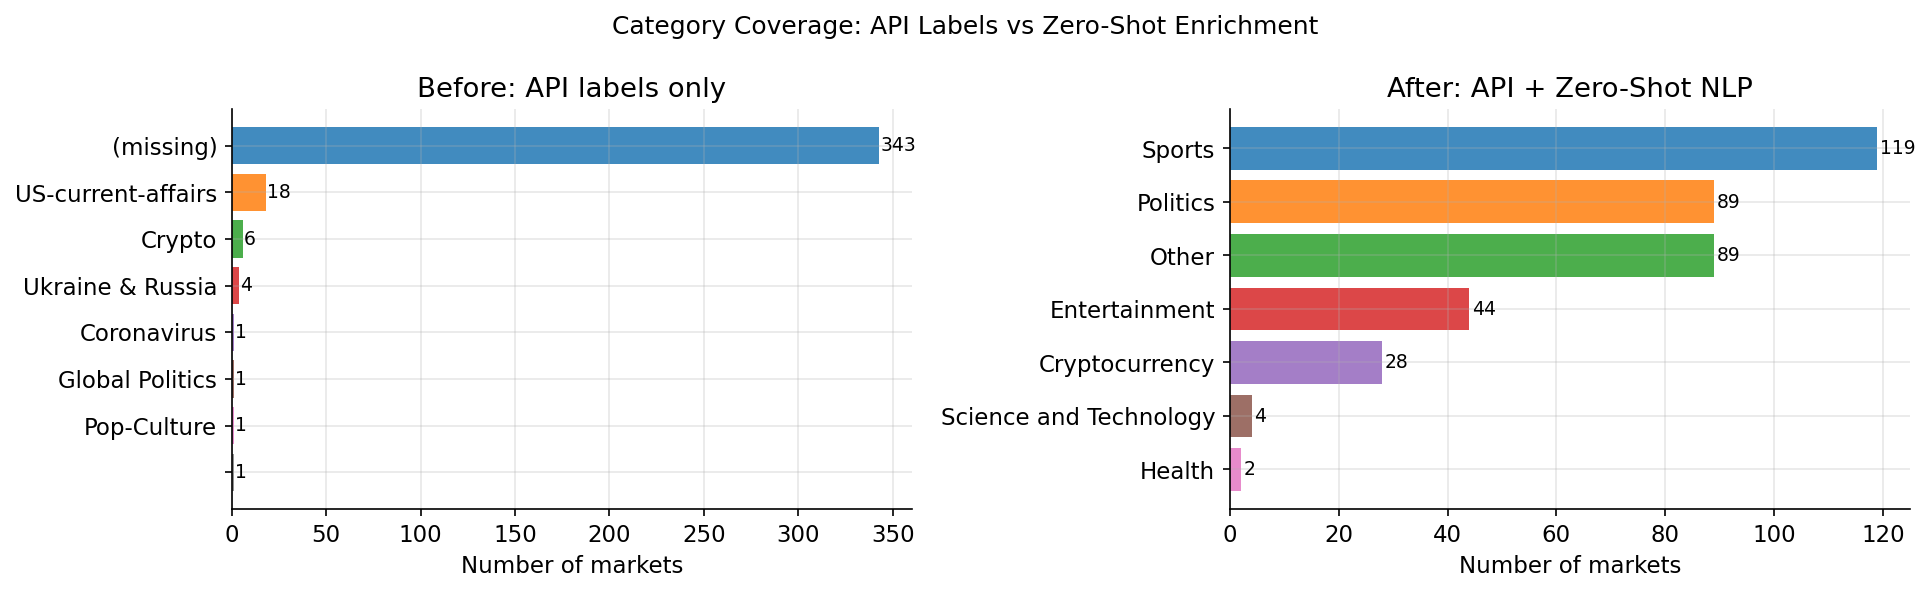

In [8]:
# Category distribution: before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

before = markets["category"].fillna("(missing)").str.strip().value_counts()
after  = markets_enriched["category_clean"].value_counts()

for ax, counts, title in [
    (axes[0], before, "Before: API labels only"),
    (axes[1], after,  "After: API + Zero-Shot NLP"),
]:
    colors = PALETTE[:len(counts)]
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_xlabel("Number of markets")
    ax.set_title(title)
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)

fig.suptitle("Category Coverage: API Labels vs Zero-Shot Enrichment", fontsize=12)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "00_category_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

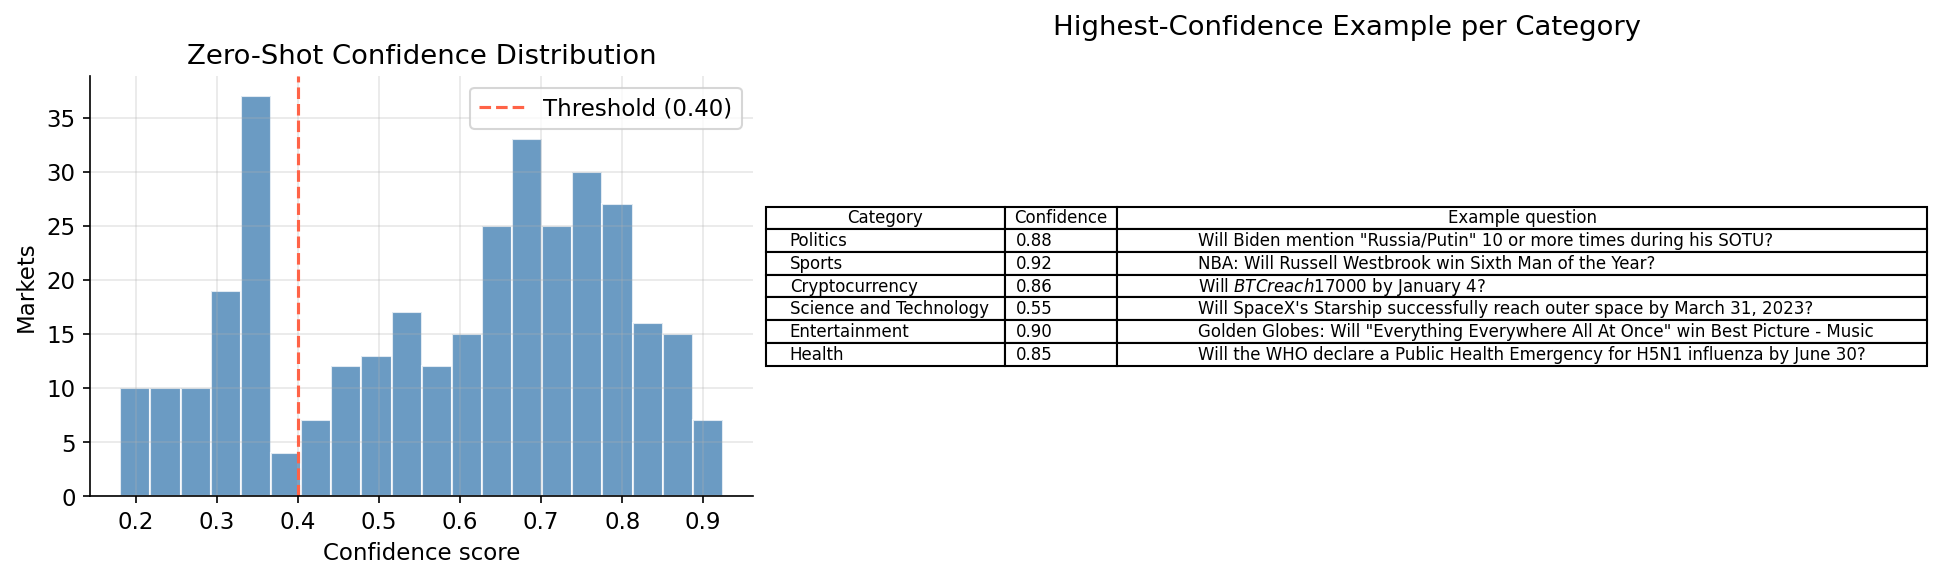

Zero-shot applied to  : 344 markets
Median confidence     : 0.64
Below threshold (<.40): 89 → labelled 'Other'


In [9]:
# Confidence distribution of zero-shot predictions
zs = markets_enriched[markets_enriched["category_source"] == "zero-shot"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(zs["category_confidence"], bins=20, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0.40, color="tomato", lw=1.5, linestyle="--", label="Threshold (0.40)")
axes[0].set_xlabel("Confidence score")
axes[0].set_ylabel("Markets")
axes[0].set_title("Zero-Shot Confidence Distribution")
axes[0].legend()

# Sample predictions per category with confidence
sample_rows = []
for cat in CATEGORIES:
    sub = zs[zs["category_clean"] == cat].nlargest(1, "category_confidence")
    if not sub.empty:
        r = sub.iloc[0]
        sample_rows.append({
            "Category": cat,
            "Confidence": f"{r['category_confidence']:.2f}",
            "Example question": r["question"][:80],
        })

axes[1].axis("off")
sample_df = pd.DataFrame(sample_rows)
tbl = axes[1].table(
    cellText=sample_df.values,
    colLabels=sample_df.columns,
    cellLoc="left", loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width([0, 1, 2])
axes[1].set_title("Highest-Confidence Example per Category", pad=20)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "00b_zeroshot_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Zero-shot applied to  : {len(zs):,} markets")
print(f"Median confidence     : {zs['category_confidence'].median():.2f}")
print(f"Below threshold (<.40): {(zs['category_confidence'] < 0.40).sum()} → labelled 'Other'")

## 3. Prepare Analysis Dataset

In [10]:
# Load enriched markets (avoids re-running model if notebook is re-executed)
markets_enriched = load_parquet(DATA_DIR / "markets_enriched.parquet")

# Per-market price stats
def market_price_stats(prices: pd.DataFrame) -> pd.DataFrame:
    out = []
    for mid, grp in prices.sort_values("timestamp").groupby("market_id"):
        p = grp["price"].values
        out.append({
            "market_id":   mid,
            "final_odds":  p[-1],
            "avg_odds":    p.mean(),
            "median_odds": np.median(p),
            "n_days":      len(p),
            "odds_std":    p.std(),
        })
    return pd.DataFrame(out)

price_stats = market_price_stats(prices)

df = markets_enriched.merge(price_stats, on="market_id", how="inner")
df["y"] = (df["outcome"] == "YES").astype(int)

print(f"Analysis dataset : {len(df):,} markets with price history")
print(f"YES: {df['y'].sum()} ({df['y'].mean():.1%})   NO: {(1-df['y']).sum()} ({(1-df['y']).mean():.1%})")
print()
print(df["category_clean"].value_counts().to_string())

Analysis dataset : 140 markets with price history
YES: 43 (30.7%)   NO: 97 (69.3%)

category_clean
Politics          48
Sports            41
Other             28
Entertainment     13
Cryptocurrency     9
Health             1


## 4. Overall Calibration

We bin markets by their **final-day implied probability** and compare against the actual resolution rate.
A perfectly calibrated market lies on the diagonal (dotted line).
Bubble size encodes the number of markets in each bin.

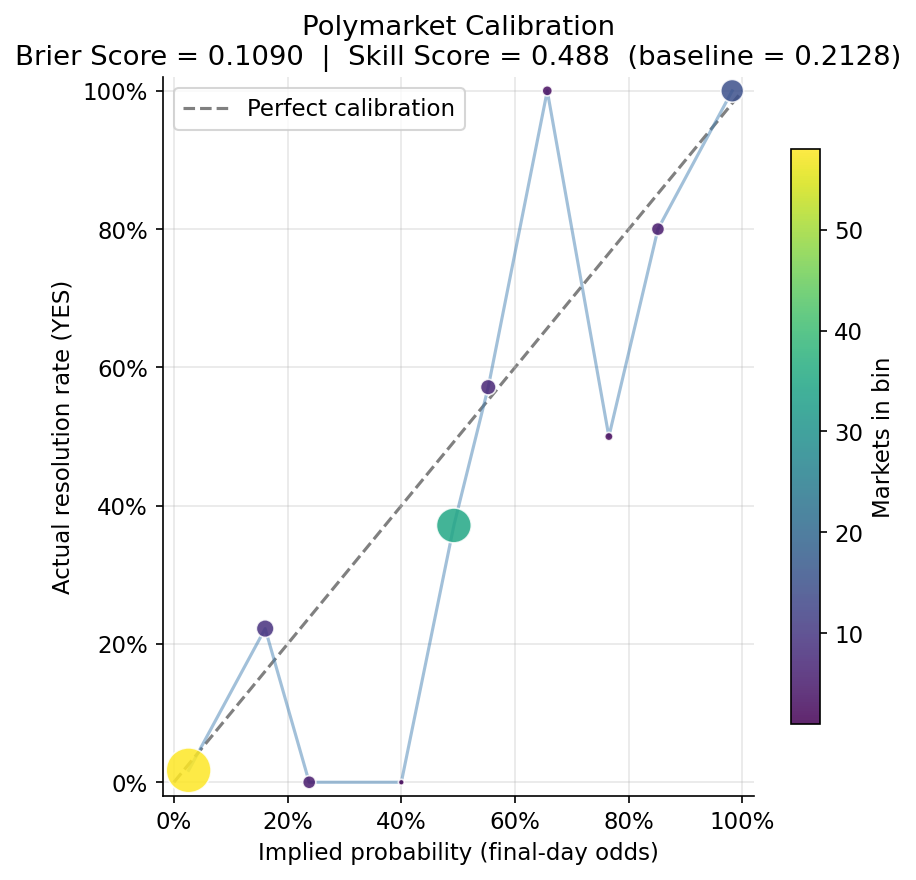

In [11]:
calib = calibration_bins(df["y"].values, df["final_odds"].values, n_bins=10)

bs  = brier_score(df["y"].values, df["final_odds"].values)
bss = brier_skill_score(df["y"].values, df["final_odds"].values)
bs_baseline = brier_score(df["y"].values, np.full(len(df), df["y"].mean()))

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Perfect calibration", zorder=1)

valid = calib.dropna(subset=["mean_forecast", "actual_rate"])
sc = ax.scatter(
    valid["mean_forecast"], valid["actual_rate"],
    s=valid["count"] * 8, alpha=0.85, zorder=3,
    c=valid["count"], cmap="viridis", edgecolors="white", linewidths=0.8,
)
ax.plot(valid["mean_forecast"], valid["actual_rate"],
        "-", color="steelblue", lw=1.5, zorder=2, alpha=0.5)

plt.colorbar(sc, ax=ax, label="Markets in bin", shrink=0.8)

ax.set_xlabel("Implied probability (final-day odds)")
ax.set_ylabel("Actual resolution rate (YES)")
ax.set_title(
    f"Polymarket Calibration\n"
    f"Brier Score = {bs:.4f}  |  Skill Score = {bss:.3f}  "
    f"(baseline = {bs_baseline:.4f})"
)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_calibration_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Calibration by Category

With enriched categories we can now ask: do some topics produce better-calibrated markets?

In [12]:
MIN_N = 5
valid_cats = df["category_clean"].value_counts()
valid_cats = valid_cats[valid_cats >= MIN_N].index.tolist()

cat_stats = []
for cat in valid_cats:
    sub = df[df["category_clean"] == cat]
    cat_stats.append({
        "category":      cat,
        "n_markets":     len(sub),
        "yes_rate":      sub["y"].mean(),
        "brier_score":   brier_score(sub["y"].values, sub["final_odds"].values),
        "brier_skill":   brier_skill_score(sub["y"].values, sub["final_odds"].values),
        "mean_final_odds": sub["final_odds"].mean(),
    })

cat_df = pd.DataFrame(cat_stats).sort_values("brier_score")
cat_df.round(4)

,category,n_markets,yes_rate,brier_score,brier_skill,mean_final_odds
4,Cryptocurrency,9,0.2222,0.0269,0.8442,0.3161
0,Politics,48,0.3125,0.0713,0.6679,0.2666
3,Entertainment,13,0.2308,0.0828,0.5338,0.3162
2,Other,28,0.3929,0.1224,0.4867,0.3620
1,Sports,41,0.2927,0.1729,0.1648,0.4446


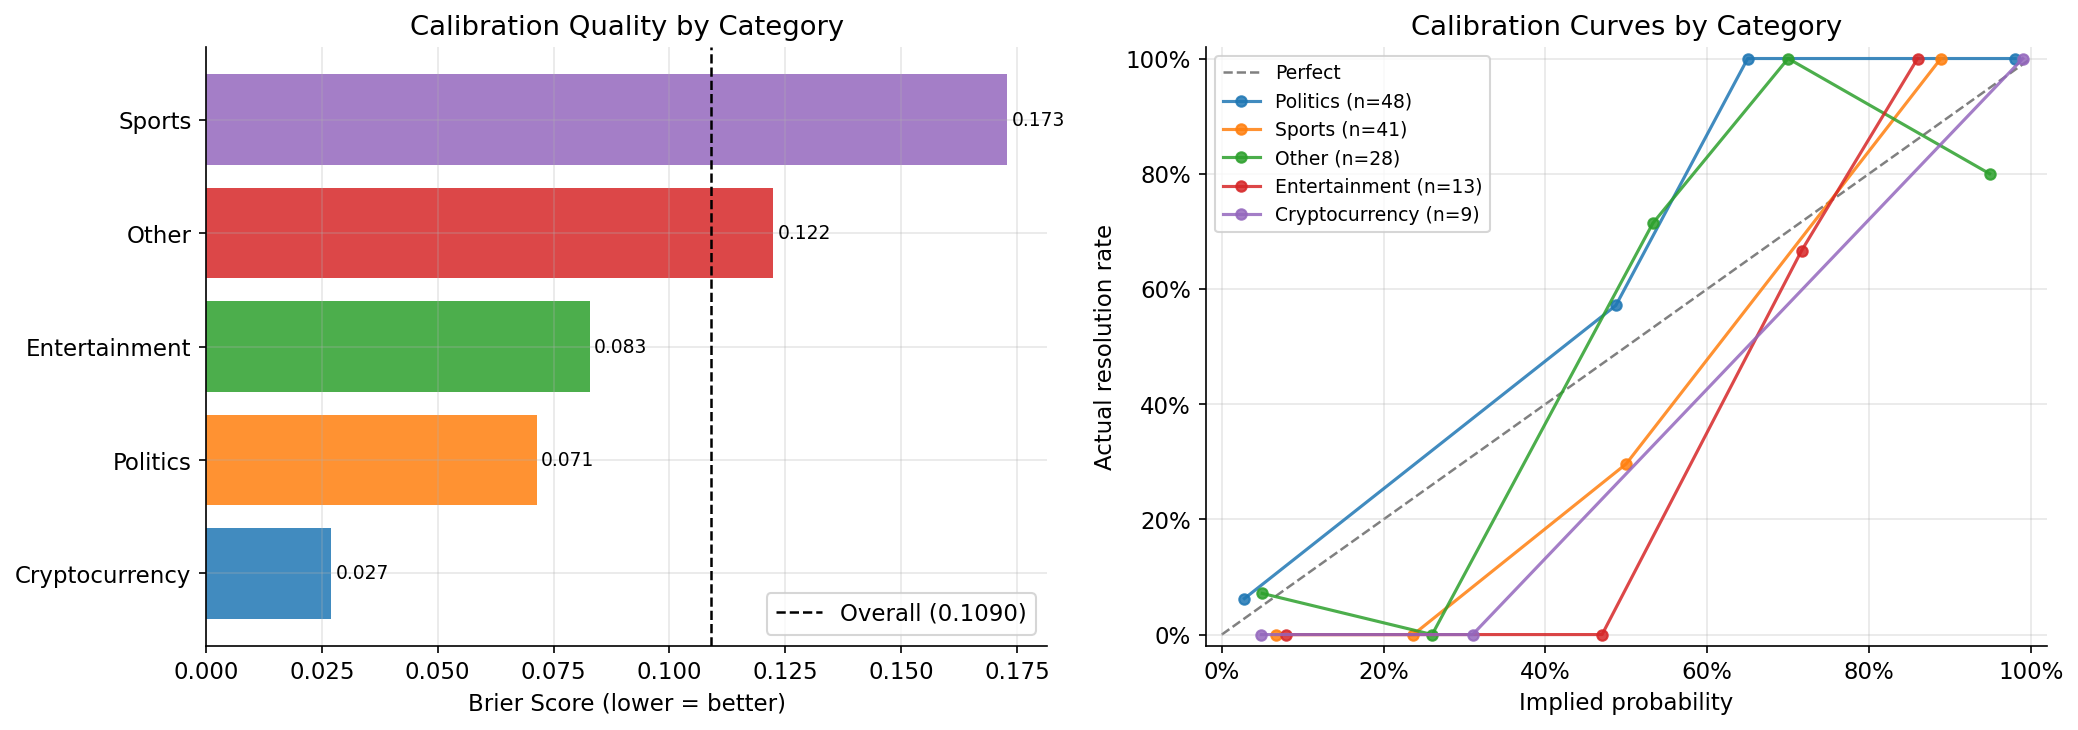

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Brier score bar chart
ax = axes[0]
colors = [PALETTE[i % 10] for i in range(len(cat_df))]
bars = ax.barh(cat_df["category"], cat_df["brier_score"], color=colors, alpha=0.85)
ax.axvline(bs, color="black", lw=1.2, linestyle="--", label=f"Overall ({bs:.4f})")
ax.set_xlabel("Brier Score (lower = better)")
ax.set_title("Calibration Quality by Category")
ax.legend()
for bar, val in zip(bars, cat_df["brier_score"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

# Right: calibration curves
ax = axes[1]
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.2, zorder=1, label="Perfect")
for i, cat in enumerate(valid_cats):
    sub = df[df["category_clean"] == cat]
    cb  = calibration_bins(sub["y"].values, sub["final_odds"].values, n_bins=5)
    cb  = cb.dropna(subset=["mean_forecast", "actual_rate"])
    if len(cb) < 2:
        continue
    ax.plot(cb["mean_forecast"], cb["actual_rate"],
            "-o", color=PALETTE[i % 10], ms=5, lw=1.5,
            label=f"{cat} (n={len(sub)})", alpha=0.85)

ax.set_xlabel("Implied probability")
ax.set_ylabel("Actual resolution rate")
ax.set_title("Calibration Curves by Category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_calibration_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Biggest Mispricings

Which markets had the largest gap between implied probability and actual outcome?

- **Positive error** (red): market overestimated YES probability → resolved NO
- **Negative error** (blue): market underestimated YES probability → resolved YES

In [14]:
df["error"]     = df["final_odds"] - df["y"]
df["abs_error"] = df["error"].abs()

top_n = 10
cols  = ["question", "category_clean", "final_odds", "outcome", "error", "volume_usd"]

top_mispriced = df.nlargest(top_n, "abs_error")[cols].copy()
top_mispriced["final_odds"] = top_mispriced["final_odds"].map("{:.1%}".format)
top_mispriced["error"]      = top_mispriced["error"].map("{:+.2f}".format)
top_mispriced["volume_usd"] = top_mispriced["volume_usd"].map("${:,.0f}".format)
top_mispriced["question"]   = top_mispriced["question"].str[:65]
print(top_mispriced.to_string(index=False))

                                                         question category_clean final_odds outcome error volume_usd
              Will Donald J. Trump be indicted by March 31, 2023?       Politics       6.0%     YES -0.94   $874,177
Will U.S. inflation be greater than 0.1% from February to March 2          Other      90.0%      NO +0.90     $1,812
            Will the "Chinese spy balloon" be down by February 5?          Other      15.0%     YES -0.85    $29,226
                   Will Hunter Biden be indicted by July 1, 2023?       Politics      16.5%     YES -0.83    $58,215
Golden Globes: Will "Everything Everywhere All At Once" win Best   Entertainment      75.0%      NO +0.75       $178
Will U.S. inflation be greater than 0.2% from February to March 2          Other      57.0%      NO +0.57     $3,725
                Will the Philadelphia Eagles win Super Bowl LVII?         Sports      54.0%      NO +0.54    $64,847
                 Will the Kansas City Chiefs win Super Bowl LVII

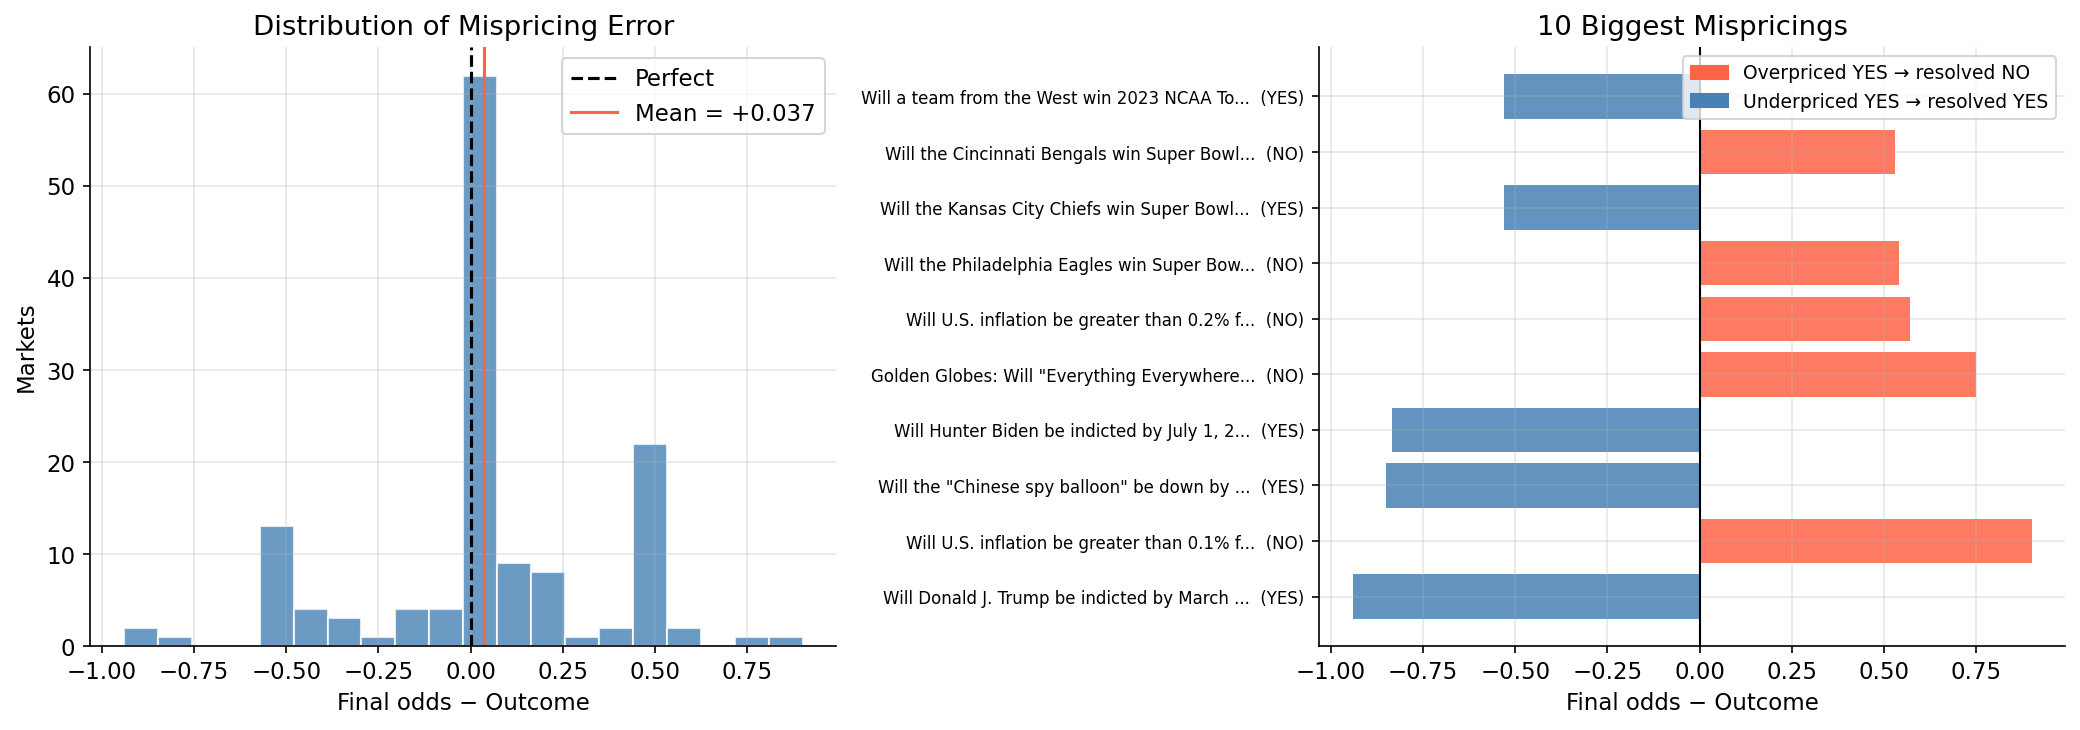

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df["error"], bins=20, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", lw=1.5, linestyle="--", label="Perfect")
ax.axvline(df["error"].mean(), color="tomato", lw=1.5,
           label=f"Mean = {df['error'].mean():+.3f}")
ax.set_xlabel("Final odds − Outcome")
ax.set_ylabel("Markets")
ax.set_title("Distribution of Mispricing Error")
ax.legend()

ax = axes[1]
worst = df.nlargest(top_n, "abs_error").copy()
worst["label"] = worst["question"].str[:42] + "...  (" + worst["outcome"] + ")"
colors = ["tomato" if e > 0 else "steelblue" for e in worst["error"]]
ax.barh(range(len(worst)), worst["error"], color=colors, alpha=0.85)
ax.set_yticks(range(len(worst)))
ax.set_yticklabels(worst["label"], fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Final odds − Outcome")
ax.set_title("10 Biggest Mispricings")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tomato",    label="Overpriced YES → resolved NO"),
    Patch(color="steelblue", label="Underpriced YES → resolved YES"),
], fontsize=9)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "03_mispricings.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Price Convergence Over Market Lifetime

We normalize each market's timeline to [0, 1] (fraction of lifetime elapsed)
and plot YES-price paths grouped by resolution.
This reveals whether markets start well-calibrated or converge only at the end.

In [16]:
norm_paths = []
for mid, grp in prices.sort_values("timestamp").groupby("market_id"):
    meta = df[df["market_id"] == mid]
    if meta.empty or len(grp) < 3:
        continue
    norm_paths.append({
        "market_id": mid,
        "outcome":   meta["y"].iloc[0],
        "category":  meta["category_clean"].iloc[0],
        "t": np.linspace(0, 1, len(grp)),
        "p": grp["price"].values,
    })

print(f"Markets with normalized paths: {len(norm_paths)}")

Markets with normalized paths: 134


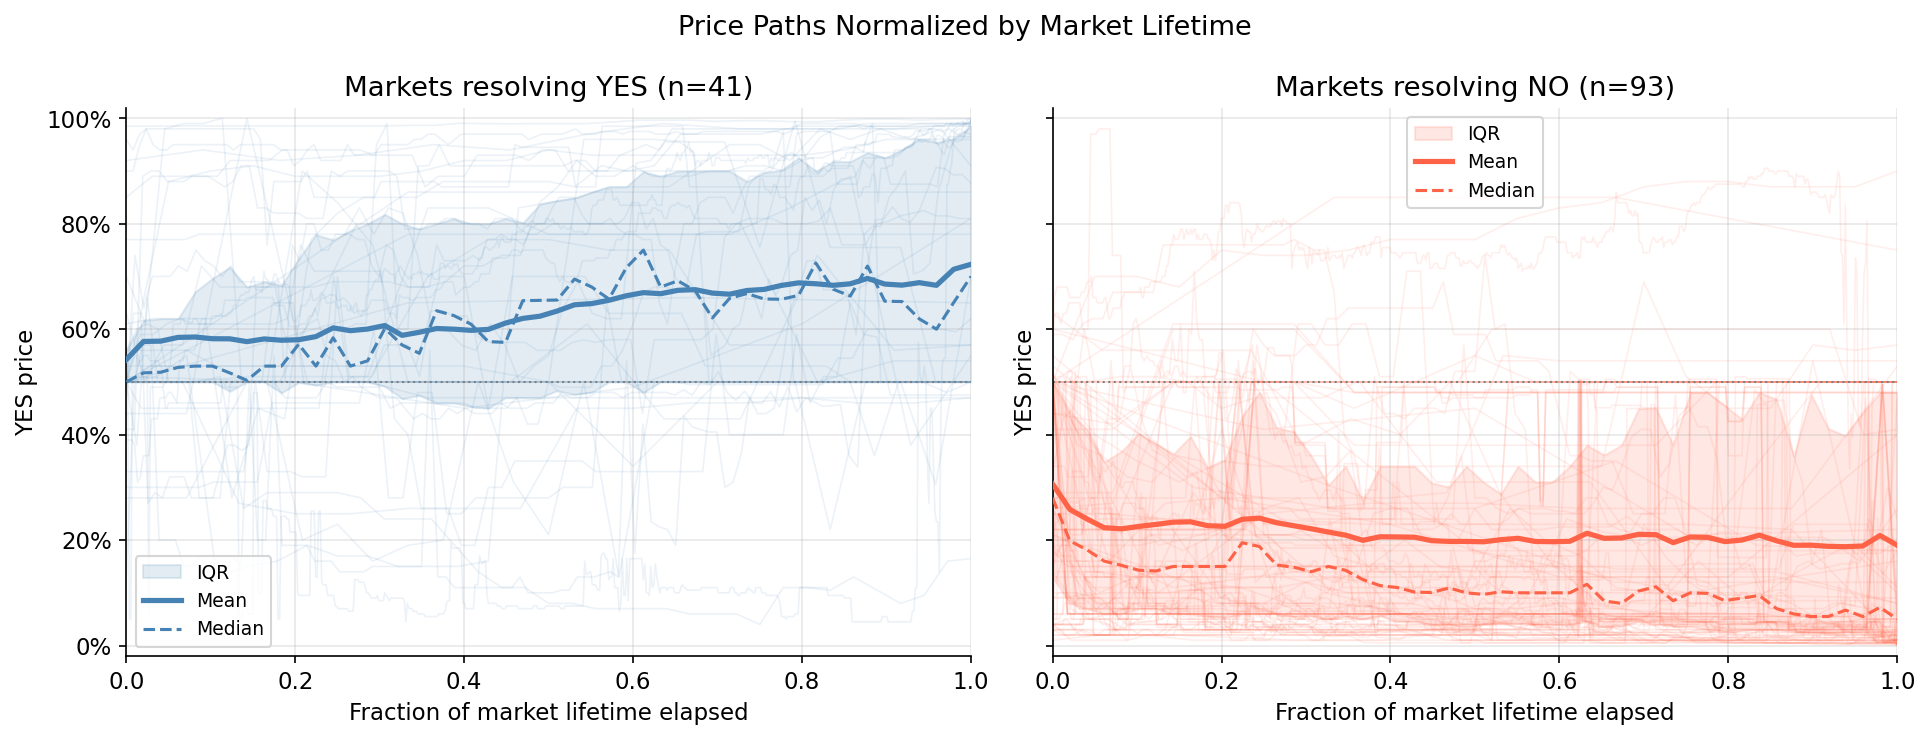

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
t_grid = np.linspace(0, 1, 50)

for ax, label, color, title in [
    (axes[0], 1, "steelblue", "Markets resolving YES"),
    (axes[1], 0, "tomato",    "Markets resolving NO"),
]:
    subset = [p for p in norm_paths if p["outcome"] == label]
    for path in subset:
        ax.plot(path["t"], path["p"], color=color, alpha=0.10, lw=0.8)

    if subset:
        mat = np.array([np.interp(t_grid, p["t"], p["p"]) for p in subset])
        ax.fill_between(t_grid, np.percentile(mat, 25, axis=0),
                        np.percentile(mat, 75, axis=0), color=color, alpha=0.15, label="IQR")
        ax.plot(t_grid, mat.mean(axis=0),           color=color, lw=2.5, label="Mean",   zorder=3)
        ax.plot(t_grid, np.median(mat, axis=0), "--", color=color, lw=1.5, label="Median", zorder=3)

    ax.axhline(0.5, color="grey", lw=1, linestyle=":")
    ax.set_xlabel("Fraction of market lifetime elapsed")
    ax.set_ylabel("YES price")
    ax.set_title(f"{title} (n={len(subset)})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)

fig.suptitle("Price Paths Normalized by Market Lifetime", fontsize=13)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "04_price_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary & Key Findings

In [18]:
best_cat  = cat_df.iloc[0]
worst_cat = cat_df.iloc[-1]
worst_mkt = df.nlargest(1, "abs_error").iloc[0]
zs_markets = markets_enriched[markets_enriched["category_source"] == "zero-shot"]

print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print(f"Dataset              : {len(df):,} resolved binary markets with price history")
print(f"Date range           : 2023-01-01 to 2024-09-10")
print()
print(f"Category enrichment  : {len(zs_markets):,} markets labelled via zero-shot NLP")
print(f"  Median confidence  : {zs_markets['category_confidence'].median():.2f}")
print()
print(f"Overall Brier Score  : {bs:.4f}  (baseline = {bs_baseline:.4f})")
print(f"Brier Skill Score    : {bss:.3f}  (1 = perfect, 0 = no skill)")
print(f"Mean mispricing      : {df['error'].mean():+.4f}  "
      f"({'slight YES overestimation' if df['error'].mean() > 0 else 'slight YES underestimation'})")
print()
print(f"Best calibrated cat  : {best_cat['category']}  "
      f"(BS={best_cat['brier_score']:.4f}, n={int(best_cat['n_markets'])})")
print(f"Worst calibrated cat : {worst_cat['category']}  "
      f"(BS={worst_cat['brier_score']:.4f}, n={int(worst_cat['n_markets'])})")
print()
print(f"Biggest mispricing   : '{worst_mkt['question'][:65]}'")
print(f"  Final odds={worst_mkt['final_odds']:.1%}, Outcome={worst_mkt['outcome']}, "
      f"Error={worst_mkt['error']:+.2f}, Category={worst_mkt['category_clean']}")

KEY FINDINGS
Dataset              : 140 resolved binary markets with price history
Date range           : 2023-01-01 to 2024-09-10

Category enrichment  : 344 markets labelled via zero-shot NLP
  Median confidence  : 0.64

Overall Brier Score  : 0.1090  (baseline = 0.2128)
Brier Skill Score    : 0.488  (1 = perfect, 0 = no skill)
Mean mispricing      : +0.0366  (slight YES overestimation)

Best calibrated cat  : Cryptocurrency  (BS=0.0269, n=9)
Worst calibrated cat : Sports  (BS=0.1729, n=41)

Biggest mispricing   : 'Will Donald J. Trump be indicted by March 31, 2023?'
  Final odds=6.0%, Outcome=YES, Error=-0.94, Category=Politics
